In [ ]:
import numpy as np
import pandas as pd
import pickle
import joblib # Add joblib import
from scipy.sparse import csr_matrix # Assuming tfidf_matrix is a sparse matrix
from google.colab import drive
drive.mount('/content/drive')


BASE_FILE_PATH = '/content/drive/MyDrive/dblp-ref/'
# Define file paths (adjust these if your files are in a different location)
PARQUET_FILE = BASE_FILE_PATH + 'papers.parquet'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
try:
    X = pd.read_parquet(PARQUET_FILE)
    print(f"Successfully loaded {PARQUET_FILE} with {len(X):,} rows and {X.shape[1]} columns.")
    display(X.head())
except FileNotFoundError:
    print(f"Error: {PARQUET_FILE} not found. Please ensure the file is in the correct directory.")
except Exception as e:
    print(f"An error occurred while loading {PARQUET_FILE}: {e}")

Successfully loaded /content/drive/MyDrive/dblp-ref/papers.parquet with 1,312,129 rows and 118 columns.


,n_citation,year,author_count,reference_count,0,1,2,3,4,5,...,svd_40,svd_41,svd_42,svd_43,svd_44,svd_45,svd_46,svd_47,svd_48,svd_49
0,-0.19671,0.410450,1.044627,-0.610855,-0.377782,0.002561,-0.648538,0.690872,-0.172070,0.518738,...,-0.115301,-0.047210,-0.074106,-0.050774,-0.010681,0.112461,0.005892,0.103556,0.024990,0.079436
1,-0.18507,-1.227527,-0.647415,-0.845134,-0.102237,-0.031323,-0.242145,0.179260,0.029811,0.191381,...,-0.115301,-0.047210,-0.074106,-0.050774,-0.010681,0.112461,0.005892,0.103556,0.024990,0.079436
2,-0.18507,-0.471537,-0.647415,-0.845134,-0.131188,-0.268309,-0.617578,0.573267,0.142074,0.657874,...,-0.115301,-0.047210,-0.074106,-0.050774,-0.010681,0.112461,0.005892,0.103556,0.024990,0.079436
3,-0.19671,0.662447,0.480613,-0.493716,-0.379827,0.278170,-0.753805,0.268149,-0.306889,-0.116411,...,-0.009860,-0.044705,0.021915,0.227307,-0.009757,-0.078639,0.002956,-0.038577,0.029151,-0.167990
4,-0.19671,-1.605522,-0.083401,-0.845134,-0.102237,-0.031323,-0.242145,0.179260,0.029811,0.191381,...,-0.115301,-0.047210,-0.074106,-0.050774,-0.010681,0.112461,0.005892,0.103556,0.024990,0.079436


In [ ]:
from sklearn.decomposition import TruncatedSVD

COLS = 10

numeric_sparse_cols = [col for col in X.columns if col.isdigit()]
svd_cols = [col for col in X.columns if col.startswith("svd_")]

sparse_columns = numeric_sparse_cols + svd_cols

X_sparse = X[sparse_columns]

svd = TruncatedSVD(n_components=COLS)

reduced = svd.fit_transform(X_sparse)

X = X.drop(columns=sparse_columns)

X = pd.concat([X, pd.DataFrame(reduced)], axis=1)

In [ ]:
# Convert all column names to strings to avoid TypeError with KMeans
X.columns = X.columns.astype(str)

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split

k_clusters = [2, 3, 5, 10, 20, 30, 50, 75, 100]

k_runs = {}

# Define the number of clusters.
for k in k_clusters:
    run = {}

    print(f"Performing KMeans clustering with {k} clusters...")

    kmeans = MiniBatchKMeans(n_clusters=k)

    cluster_labels = kmeans.fit_predict(X)

    print(f"{k}-Means Clustering complete. Compiling scores...")

    run['sse'] = kmeans.inertia_ / len(cluster_labels)

    sample_size = 0.05
    X_sample, _, cluster_labels_sample, _ = train_test_split(
        X,
        cluster_labels,
        test_size=(1 - sample_size),
        random_state=42,
        stratify=cluster_labels
    )

    run['silhouette'] = silhouette_score(X_sample, cluster_labels_sample)

    run['davies'] = davies_bouldin_score(X, cluster_labels)

    k_runs[k] = run

    print(f"{k}-Means scoring complete!")

Performing KMeans clustering with 2 clusters...
2-Means Clustering complete. Compiling scores...
2-Means scoring complete!
Performing KMeans clustering with 3 clusters...
3-Means Clustering complete. Compiling scores...
3-Means scoring complete!
Performing KMeans clustering with 5 clusters...
5-Means Clustering complete. Compiling scores...
5-Means scoring complete!
Performing KMeans clustering with 10 clusters...
10-Means Clustering complete. Compiling scores...
10-Means scoring complete!
Performing KMeans clustering with 20 clusters...
20-Means Clustering complete. Compiling scores...
20-Means scoring complete!
Performing KMeans clustering with 30 clusters...
30-Means Clustering complete. Compiling scores...
30-Means scoring complete!
Performing KMeans clustering with 50 clusters...
50-Means Clustering complete. Compiling scores...
50-Means scoring complete!
Performing KMeans clustering with 75 clusters...
75-Means Clustering complete. Compiling scores...
75-Means scoring complete!
P

In [ ]:
rows = []
for k in k_clusters:
    run = k_runs[k]
    rows.append([
        k, run['sse'], run['silhouette'], run['davies']
    ])

kmeans_table = pd.DataFrame(rows, columns=[
    "k", "SSE", "Silhouette", "Davies"
])

display(kmeans_table)

,k,SSE,Silhouette,Davies
0,2,36.445663,0.639259,1.793258
1,3,34.573850,0.487346,2.229662
2,5,31.795740,0.118087,2.597639
3,10,26.140697,0.130524,1.967320
4,20,22.548869,0.045111,1.929584
5,30,19.476995,0.056971,1.816074
6,50,16.493081,0.055420,1.748482
7,75,15.346348,0.042499,1.890952
8,100,13.896973,0.047776,1.820539


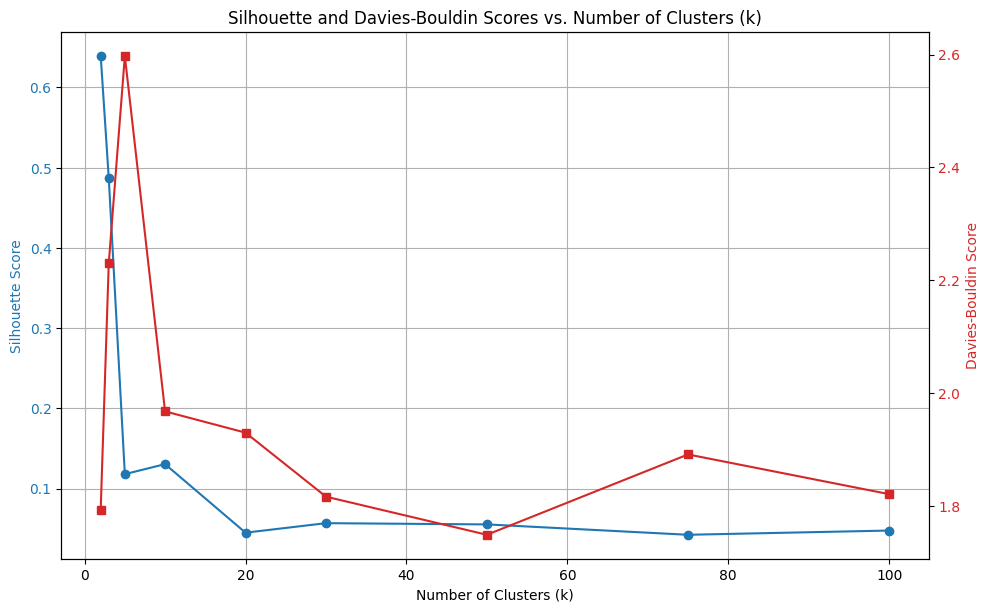

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Silhouette Score on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(kmeans_table['k'], kmeans_table['Silhouette'], marker='o', color=color, label='Silhouette')
ax1.tick_params(axis='y', labelcolor=color)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()

# Plot Davies-Bouldin Score on the right y-axis
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Score', color=color)
ax2.plot(kmeans_table['k'], kmeans_table['Davies'], marker='s', color=color, label='Davies-Bouldin')
ax2.tick_params(axis='y', labelcolor=color)

# Layout and grid
fig.tight_layout()
plt.title('Silhouette and Davies-Bouldin Scores vs. Number of Clusters (k)')
ax1.grid(True)
plt.show()

In [ ]:
# Import custom SSE for rest of clustering algos
def compute_sse(x: np.ndarray, y_pred: np.ndarray) -> float:
    x = np.asarray(x)
    y_pred = np.asarray(y_pred)

    n = x.shape[0]
    total_sse = 0.0

    for cluster in np.unique(y_pred):
        cluster_points = x[y_pred == cluster]
        centroid = cluster_points.mean(axis=0)
        # Sum of squared Euclidean distances within the cluster.
        total_sse += np.sum((cluster_points - centroid) ** 2)

    return float(total_sse / n)

from sklearn.cluster import DBSCAN
epsilon_values = [0.8, 0.9, 1.0, 1.1, 1.2]
eps_runs = {}

X_small = X.sample(10_000)

for eps in epsilon_values:
    print(f"Starting run with epsilon eps={eps}")
    eps_run = {}
    dbscan = DBSCAN(eps=eps, min_samples=10, metric="euclidean", n_jobs=-1)
    cluster_labels = dbscan.fit_predict(X_small)
    print(f"Clusters complete! Scoring model...")
    eps_run['num_clusters'] = len(np.unique(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    # Get anomalies
    eps_run['n_anomalies'] = np.sum(cluster_labels == -1)
    # Get rid of anomalies
    mask = cluster_labels != -1
    X_clean = X_small[mask]
    labels_clean = cluster_labels[mask]
    eps_run['sse'] = compute_sse(X_clean, labels_clean)
    if len(np.unique(labels_clean)) < 2:
        eps_run['silhouette'] = None
    else:
        eps_run['silhouette'] = silhouette_score(X_clean, labels_clean, metric='euclidean')

    eps_run['davies'] = davies_bouldin_score(X_small, cluster_labels)
    eps_runs[eps] = eps_run
    print(f"Run ended with DBSCAN model with eps={eps}")


rows = []
for eps in epsilon_values:
    run = eps_runs[eps]
    rows.append([
        eps,
        run['num_clusters'],
        run['n_anomalies'],
        run['sse'],
        run['silhouette'],
        run['davies']
    ])

dbscan_table = pd.DataFrame(rows, columns=[
    'eps', 'Number of Clusters', 'Number of Anomalies',
    'SSE', 'Silhouette Coefficient', 'Davies-Bouldin'
])

display(dbscan_table)

Starting run with epsilon eps=0.8
Clusters complete! Scoring model...
Run ended with DBSCAN model with eps=0.8
Starting run with epsilon eps=0.9
Clusters complete! Scoring model...
Run ended with DBSCAN model with eps=0.9
Starting run with epsilon eps=1.0
Clusters complete! Scoring model...
Run ended with DBSCAN model with eps=1.0
Starting run with epsilon eps=1.1
Clusters complete! Scoring model...
Run ended with DBSCAN model with eps=1.1
Starting run with epsilon eps=1.2
Clusters complete! Scoring model...
Run ended with DBSCAN model with eps=1.2


,eps,Number of Clusters,Number of Anomalies,SSE,Silhouette Coefficient,Davies-Bouldin
0,0.8,4,8562,1.931130,0.096080,2.878198
1,0.9,4,8333,1.977184,0.118477,2.932857
2,1.0,2,8106,2.753607,0.194499,3.071863
3,1.1,3,7858,2.955348,0.158519,2.814800
4,1.2,2,7613,3.175284,0.273838,2.916874


In [ ]:
TFIDF_MATRIX = BASE_FILE_PATH + 'tfidf_matrix.pkl'
TFIDF_VECTORIZER = BASE_FILE_PATH + 'tfidf_vectorizer.pkl'

X_tfidf = joblib.load(TFIDF_MATRIX)
v_tfidf = joblib.load(TFIDF_VECTORIZER)

In [ ]:
# Information about the loaded TF-IDF matrix
print(f"TF-IDF Matrix shape: {X_tfidf.shape}")
print(f"TF-IDF Matrix type: {type(X_tfidf)}")
print(f"Number of non-zero elements: {X_tfidf.nnz}")

TF-IDF Matrix shape: (1042403, 2500)
TF-IDF Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Number of non-zero elements: 49882176


In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
import numpy as np

k_clusters_tfidf = [2, 3, 5, 10, 20, 30, 50, 75, 100]
k_runs_tfidf = {}

# Define the number of clusters.
for k in k_clusters_tfidf:
    run = {}
    print(f"Performing KMeans clustering on TF-IDF with {k} clusters...")

    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_tfidf)

    print(f"{k}-Means Clustering complete. Compiling scores...")

    run['sse'] = kmeans.inertia_ / X_tfidf.shape[0]

    # Use a small sample size (1%) due to high dimensionality and dataset size
    sample_size = 0.01

    # Removed stratify=cluster_labels to avoid ValueError on clusters with only 1 item
    X_sample, _, cluster_labels_sample, _ = train_test_split(
        X_tfidf,
        cluster_labels,
        test_size=(1 - sample_size),
        random_state=42
    )

    # Convert the small sample to a dense array for the scoring functions
    X_sample_dense = X_sample.toarray()

    # Ensure we have at least 2 clusters in the sample to calculate metrics
    if len(np.unique(cluster_labels_sample)) > 1:
        run['silhouette'] = silhouette_score(X_sample_dense, cluster_labels_sample)
        run['davies'] = davies_bouldin_score(X_sample_dense, cluster_labels_sample)
    else:
        run['silhouette'] = None
        run['davies'] = None

    k_runs_tfidf[k] = run
    print(f"{k}-Means scoring complete!")

# Compile the results into a DataFrame
rows = []
for k in k_clusters_tfidf:
    run = k_runs_tfidf[k]
    rows.append([
        k, run['sse'], run['silhouette'], run['davies']
    ])

kmeans_tfidf_table = pd.DataFrame(rows, columns=[
    "k", "SSE", "Silhouette", "Davies"
])

display(kmeans_tfidf_table)

Performing KMeans clustering on TF-IDF with 2 clusters...
2-Means Clustering complete. Compiling scores...
2-Means scoring complete!
Performing KMeans clustering on TF-IDF with 3 clusters...
3-Means Clustering complete. Compiling scores...
3-Means scoring complete!
Performing KMeans clustering on TF-IDF with 5 clusters...
5-Means Clustering complete. Compiling scores...
5-Means scoring complete!
Performing KMeans clustering on TF-IDF with 10 clusters...
10-Means Clustering complete. Compiling scores...
10-Means scoring complete!
Performing KMeans clustering on TF-IDF with 20 clusters...
20-Means Clustering complete. Compiling scores...
20-Means scoring complete!
Performing KMeans clustering on TF-IDF with 30 clusters...
30-Means Clustering complete. Compiling scores...
30-Means scoring complete!
Performing KMeans clustering on TF-IDF with 50 clusters...
50-Means Clustering complete. Compiling scores...
50-Means scoring complete!
Performing KMeans clustering on TF-IDF with 75 clusters..

,k,SSE,Silhouette,Davies
0,2,0.970294,0.003936,13.108152
1,3,0.967213,0.003916,13.181336
2,5,0.962261,0.004680,11.313567
3,10,0.952282,0.005869,10.178461
4,20,0.936600,0.008656,8.143411
5,30,0.926395,0.010576,7.317175
6,50,0.912088,0.013613,6.407019
7,75,0.903145,0.013926,5.851988
8,100,0.886964,0.020459,5.498150


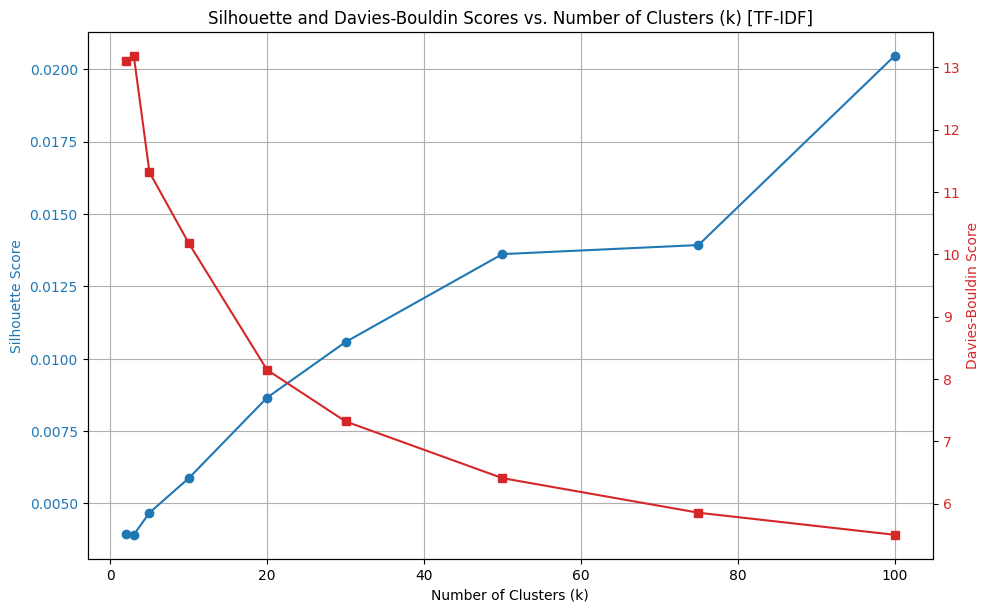

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Silhouette Score on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(kmeans_tfidf_table['k'], kmeans_tfidf_table['Silhouette'], marker='o', color=color, label='Silhouette')
ax1.tick_params(axis='y', labelcolor=color)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()

# Plot Davies-Bouldin Score on the right y-axis
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Score', color=color)
ax2.plot(kmeans_tfidf_table['k'], kmeans_tfidf_table['Davies'], marker='s', color=color, label='Davies-Bouldin')
ax2.tick_params(axis='y', labelcolor=color)

# Layout and grid
fig.tight_layout()
plt.title('Silhouette and Davies-Bouldin Scores vs. Number of Clusters (k) [TF-IDF]')
ax1.grid(True)
plt.show()

### Dimensionality Reduction on TF-IDF (LSA)
Let's apply `TruncatedSVD` to reduce the sparse 2,500-dimensional TF-IDF matrix into a lower-dimensional dense representation (100 components).

In [ ]:
from sklearn.decomposition import TruncatedSVD

N_COMPONENTS_TFIDF = 100

print(f"Applying TruncatedSVD with {N_COMPONENTS_TFIDF} components to the TF-IDF matrix...")
svd_tfidf = TruncatedSVD(n_components=N_COMPONENTS_TFIDF, random_state=42)
X_tfidf_reduced = svd_tfidf.fit_transform(X_tfidf)

print(f"Original TF-IDF shape: {X_tfidf.shape}")
print(f"Reduced TF-IDF shape: {X_tfidf_reduced.shape}")
print(f"Total explained variance ratio: {svd_tfidf.explained_variance_ratio_.sum():.4f}")

Applying TruncatedSVD with 100 components to the TF-IDF matrix...
Original TF-IDF shape: (1042403, 2500)
Reduced TF-IDF shape: (1042403, 100)
Total explained variance ratio: 0.1940


### K-Means Clustering on SVD-Reduced TF-IDF
Now we will evaluate KMeans on the dense 100-dimension feature space.

In [ ]:
k_clusters_reduced = [2, 3, 5, 10, 20, 30, 50, 75, 100]
k_runs_reduced = {}

print("Clustering on SVD-reduced TF-IDF...")
for k in k_clusters_reduced:
    run = {}
    print(f"Performing KMeans clustering with {k} clusters...")

    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_tfidf_reduced)

    run['sse'] = kmeans.inertia_ / X_tfidf_reduced.shape[0]

    # The data is dense now, but we still have over 1M rows. Let's sample 5% for faster metric scoring.
    sample_size = 0.05
    X_sample, _, cluster_labels_sample, _ = train_test_split(
        X_tfidf_reduced,
        cluster_labels,
        test_size=(1 - sample_size),
        random_state=42
    )

    if len(np.unique(cluster_labels_sample)) > 1:
        run['silhouette'] = silhouette_score(X_sample, cluster_labels_sample)
        run['davies'] = davies_bouldin_score(X_sample, cluster_labels_sample)
    else:
        run['silhouette'] = None
        run['davies'] = None

    k_runs_reduced[k] = run
    print(f"{k}-Means scoring complete!")

# Compile the results into a DataFrame
rows = []
for k in k_clusters_reduced:
    run = k_runs_reduced[k]
    rows.append([
        k, run['sse'], run['silhouette'], run['davies']
    ])

kmeans_reduced_table = pd.DataFrame(rows, columns=[
    "k", "SSE", "Silhouette", "Davies"
])

display(kmeans_reduced_table)

Clustering on SVD-reduced TF-IDF...
Performing KMeans clustering with 2 clusters...
2-Means scoring complete!
Performing KMeans clustering with 3 clusters...
3-Means scoring complete!
Performing KMeans clustering with 5 clusters...
5-Means scoring complete!
Performing KMeans clustering with 10 clusters...
10-Means scoring complete!
Performing KMeans clustering with 20 clusters...
20-Means scoring complete!
Performing KMeans clustering with 30 clusters...
30-Means scoring complete!
Performing KMeans clustering with 50 clusters...
50-Means scoring complete!
Performing KMeans clustering with 75 clusters...
75-Means scoring complete!
Performing KMeans clustering with 100 clusters...
100-Means scoring complete!


,k,SSE,Silhouette,Davies
0,2,0.185448,0.048111,5.576009
1,3,0.181374,0.061299,4.714085
2,5,0.177295,0.064885,3.959251
3,10,0.166782,0.037837,3.677499
4,20,0.151346,0.030729,3.149310
5,30,0.141030,0.040752,2.817327
6,50,0.125555,0.044942,2.489845
7,75,0.113859,0.056171,2.319322
8,100,0.107007,0.048679,2.436424


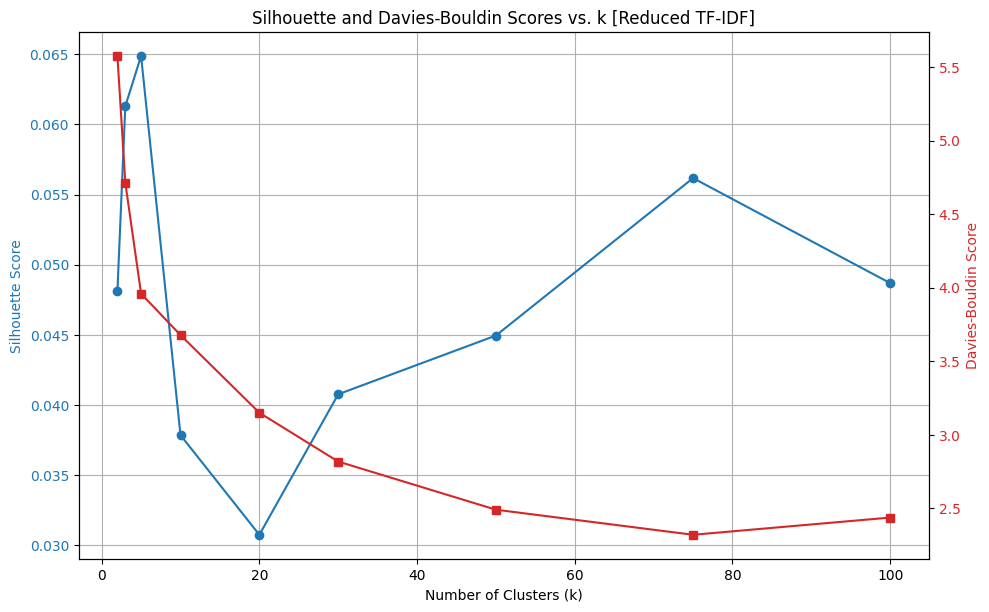

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Silhouette Score on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(kmeans_reduced_table['k'], kmeans_reduced_table['Silhouette'], marker='o', color=color, label='Silhouette')
ax1.tick_params(axis='y', labelcolor=color)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()

# Plot Davies-Bouldin Score on the right y-axis
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Score', color=color)
ax2.plot(kmeans_reduced_table['k'], kmeans_reduced_table['Davies'], marker='s', color=color, label='Davies-Bouldin')
ax2.tick_params(axis='y', labelcolor=color)

# Layout and grid
fig.tight_layout()
plt.title('Silhouette and Davies-Bouldin Scores vs. k [Reduced TF-IDF]')
ax1.grid(True)
plt.show()

### Extracting Top Terms per Cluster
Let's evaluate the actual semantic meaning of the clusters by selecting an optimal $k$ (e.g., $k=5$), clustering the reduced TF-IDF data, and then mapping the cluster centers back to the original vocabulary using `inverse_transform`.

In [ ]:
OPTIMAL_K = 5
print(f"Extracting top terms for k={OPTIMAL_K}...\n")

# 1. Fit KMeans with the optimal k
kmeans_optimal = MiniBatchKMeans(n_clusters=OPTIMAL_K, random_state=42)
kmeans_optimal.fit(X_tfidf_reduced)

# 2. Map the cluster centers in the 100-D space back to the 2500-D TF-IDF space
original_space_centroids = svd_tfidf.inverse_transform(kmeans_optimal.cluster_centers_)

# 3. Get the original words (feature names) from the TF-IDF Vectorizer
terms = v_tfidf.get_feature_names_out()

# 4. Extract and print the top N terms for each cluster
n_terms = 15
for i in range(OPTIMAL_K):
    # argsort sorts ascending, so we reverse it with [::-1] to get descending order
    top_indices = original_space_centroids[i].argsort()[::-1][:n_terms]
    top_terms = [terms[ind] for ind in top_indices]
    print(f"Cluster {i}:")
    print(f"  {', '.join(top_terms)}\n")


Extracting top terms for k=5...

Cluster 0:
  power, energy, consumption, sensor, voltage, network, low, control, wireless, networks, proposed, efficiency, design, based, paper

Cluster 1:
  recognition, classification, speech, feature, features, learning, based, data, method, using, face, training, proposed, model, classifier

Cluster 2:
  data, based, model, time, paper, algorithm, systems, using, method, control, problem, information, approach, design, results

Cluster 3:
  image, images, segmentation, method, based, color, algorithm, using, proposed, detection, object, approach, model, results, resolution

Cluster 4:
  channel, interference, performance, scheme, channels, rate, mimo, multiple, error, proposed, frequency, fading, codes, wireless, transmission



### Overlapping Topics with NMF
Non-Negative Matrix Factorization allows for "soft clustering" or topic modeling, where each paper is represented as a mixture of multiple topics.

In [ ]:
from sklearn.decomposition import NMF

N_TOPICS = 5

print(f"Applying NMF with {N_TOPICS} topics to the original TF-IDF matrix...")
# max_iter is set to 200, which is standard, but can be increased if it doesn't converge
nmf_model = NMF(n_components=N_TOPICS, random_state=42, max_iter=200)

# W_nmf is the Document-Topic matrix (how much of each topic is in each paper)
W_nmf = nmf_model.fit_transform(X_tfidf)

# H_nmf is the Topic-Term matrix (how much each word contributes to each topic)
H_nmf = nmf_model.components_

print(f"NMF complete! Document-Topic matrix shape: {W_nmf.shape}")

Applying NMF with 5 topics to the original TF-IDF matrix...
NMF complete! Document-Topic matrix shape: (1042403, 5)


In [ ]:
print("Top terms for each NMF Topic:\n")

n_terms = 15
# We already have the terms from v_tfidf

for topic_idx, topic in enumerate(H_nmf):
    # Sort the weights in the Topic-Term matrix to find the top words
    top_indices = topic.argsort()[::-1][:n_terms]
    top_terms = [terms[i] for i in top_indices]
    print(f"Topic {topic_idx}:")
    print(f"  {', '.join(top_terms)}\n")

Top terms for each NMF Topic:

Topic 0:
  image, images, method, based, detection, recognition, using, features, feature, classification, segmentation, proposed, object, video, methods

Topic 1:
  channel, network, power, networks, wireless, scheme, performance, energy, rate, interference, transmission, channels, frequency, proposed, multiple

Topic 2:
  data, information, software, web, user, design, model, systems, based, research, learning, development, knowledge, use, applications

Topic 3:
  control, robot, controller, model, systems, fuzzy, nonlinear, time, design, stability, feedback, adaptive, tracking, proposed, motion

Topic 4:
  algorithm, problem, algorithms, optimization, problems, graph, time, search, method, number, solution, optimal, set, graphs, linear



In [ ]:
sample_indices = [0, 42, 1024, 50000, 100000]

print("Topic weights for sample papers (Notice how papers can have strong weights in multiple topics):")
overlap_df = pd.DataFrame(
    W_nmf[sample_indices],
    columns=[f"Topic {i}" for i in range(N_TOPICS)],
    index=[f"Paper Index {i}" for i in sample_indices]
)

display(overlap_df.style.background_gradient(cmap='Blues', axis=1))

Topic weights for sample papers (Notice how papers can have strong weights in multiple topics):


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4
Paper Index 0,0.004457,0.000000,0.013700,0.000000,0.003377
Paper Index 42,0.001308,0.000000,0.005692,0.007755,0.008809
Paper Index 1024,0.010556,0.000000,0.001348,0.000000,0.000000
Paper Index 50000,0.000443,0.000000,0.024733,0.005716,0.001337
Paper Index 100000,0.000000,0.000492,0.014368,0.004297,0.000000


### Exploring a Larger Number of Topics (NMF)
Let's expand our search to 15 topics to see more granular themes.

In [ ]:
N_TOPICS_LARGE = 15

print(f"Applying NMF with {N_TOPICS_LARGE} topics to the original TF-IDF matrix...")
nmf_model_large = NMF(n_components=N_TOPICS_LARGE, random_state=42, max_iter=200)

# W_nmf_large is the Document-Topic matrix
W_nmf_large = nmf_model_large.fit_transform(X_tfidf)

# H_nmf_large is the Topic-Term matrix
H_nmf_large = nmf_model_large.components_

print(f"NMF complete! Document-Topic matrix shape: {W_nmf_large.shape}")

Applying NMF with 15 topics to the original TF-IDF matrix...


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


NMF complete! Document-Topic matrix shape: (1042403, 15)


In [ ]:
print(f"Top terms for each of the {N_TOPICS_LARGE} NMF Topics:\n")

n_terms_large = 10

for topic_idx, topic in enumerate(H_nmf_large):
    top_indices = topic.argsort()[::-1][:n_terms_large]
    top_terms_large = [terms[i] for i in top_indices]
    print(f"Topic {topic_idx}:")
    print(f"  {', '.join(top_terms_large)}\n")

Top terms for each of the 15 NMF Topics:

Topic 0:
  method, estimation, time, noise, signal, methods, using, proposed, filter, based

Topic 1:
  channel, interference, channels, mimo, multiple, scheme, fading, performance, rate, frequency

Topic 2:
  web, user, information, users, service, services, mobile, social, content, based

Topic 3:
  control, robot, controller, systems, feedback, motion, robots, tracking, nonlinear, stability

Topic 4:
  algorithm, problem, algorithms, optimization, search, problems, optimal, solution, genetic, proposed

Topic 5:
  network, networks, wireless, nodes, routing, sensor, traffic, protocol, neural, node

Topic 6:
  data, mining, analysis, clustering, database, large, gene, sets, processing, information

Topic 7:
  software, design, systems, development, process, research, engineering, architecture, computer, applications

Topic 8:
  model, models, modeling, simulation, based, parameters, process, markov, prediction, approach

Topic 9:
  graph, grap

### Assigning Primary Topic Tags (NMF)
We will use the 15-topic NMF model to assign a single primary label to each paper, provided its highest topic weight is above 0.05.

In [ ]:
import numpy as np
import pandas as pd

# Find the topic with the maximum weight for each paper
dominant_topic = np.argmax(W_nmf_large, axis=1)
max_weights = np.max(W_nmf_large, axis=1)

# Create a DataFrame to hold the results
topic_assignments = pd.DataFrame({
    'dominant_topic': dominant_topic,
    'max_weight': max_weights
})

# Apply the 0.05 threshold
# If the max weight is <= 0.05, assign -1 (or NaN) to indicate no strong topic
WEIGHT_THRESHOLD = 0.05
topic_assignments['assigned_tag'] = np.where(
    topic_assignments['max_weight'] > WEIGHT_THRESHOLD,
    topic_assignments['dominant_topic'],
    -1
)

# Count how many papers were assigned to each topic (or left unassigned)
tag_counts = topic_assignments['assigned_tag'].value_counts().sort_index()

print(f"Total papers: {len(topic_assignments):,}")
print(f"Papers assigned a topic (weight > {WEIGHT_THRESHOLD}): {(topic_assignments['assigned_tag'] != -1).sum():,}")
print(f"Papers left unassigned (weight <= {WEIGHT_THRESHOLD}): {(topic_assignments['assigned_tag'] == -1).sum():,}\n")

print("Distribution of Assigned Tags:")
print(tag_counts)

Total papers: 1,042,403
Papers assigned a topic (weight > 0.05): 24,838
Papers left unassigned (weight <= 0.05): 1,017,565

Distribution of Assigned Tags:
assigned_tag
-1     1017565
 1         367
 2         635
 3         140
 4          49
 5           1
 6         789
 7          20
 8          46
 9        3137
 10       1559
 11        413
 12       3419
 13       5940
 14       8323
Name: count, dtype: int64
